In [1]:
library(pROC)
library(caret)
library(dplyr)
library(glmnet)
library(parallel)
library(ggplot2)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: lattice


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix

Loaded glmnet 4.1-8



In [13]:
load("/vol/projects/yzhang/500FG_aging/output/12_prediction/cytokine_prediction_results_spearman_select.Rdata")

In [2]:
basicPhenos = read.csv("/vol/projects/yzhang/500FG_aging/output/02_Olink/Age_group_basicPhenos.csv")
head(basicPhenos)
#basicPhenos <- basicPhenos[!is.na(basicPhenos$Age), ] None missing value
dim(basicPhenos)

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,2,HV043,male,18,182,50,15.09480,Married,University student,European,Rarely,Yes,Yes,16,12,346,2013,Group 1
2,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
3,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
4,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
5,56,HV497,female,18,157,49,19.87910,Married,Hogeschool opleiding (HBO),Asian,Rarely,No,No,24,11,324,2014,Group 1
6,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1


[1] 527  18

In [3]:
#cytokine <- read.csv("/vol/projects/CIIM/cohorts_old/500FG/Molecular_phenotype/pheno_91cytokines_4Raul.csv", sep = ",")
# cytokine <- read.csv("/vol/projects/yzhang/500FG_aging/output/01_cytokine/filtered_stimulation_cytokine_filled.csv") #use mean value filled the missing value
# rownames(cytokine) <- cytokine[,1]
# cytokine <- cytokine[,-1]
# head(cytokine)
# dim(cytokine) #489samples 91 cytokines
# sum(is.na(cytokine))

,HV001,HV002,HV003,HV004,HV005,HV006,HV007,HV008,HV009,HV011,⋯,HV525,HV526,HV527,HV528,HV529,HV530,HV531,HV532,HV533,HV534
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IFNy_LPS_WB_48h,10.828930,9.457381,8.413628,5.643856,8.957102,8.774787,5.672425,9.167418,8.487840,5.807355,⋯,8.179909,7.276124,8.455327,9.652845,10.049849,10.419960,9.665336,10.359750,6.754888,9.558421
IFNy_PHA_WB_48h,10.710806,8.761551,10.884934,5.285402,8.179909,6.727920,5.285402,11.437752,7.044394,6.066089,⋯,6.475733,9.346514,8.252665,8.243174,8.326429,9.912889,7.087463,9.057992,5.643856,9.968667
IFNy_C.conidiaHK_WB_48h,8.965784,9.511753,5.857981,5.285402,5.700440,5.781360,6.228819,8.640245,8.523562,5.285402,⋯,5.643856,5.491853,7.982994,7.727920,10.369597,5.285402,10.041659,5.459432,7.459432,5.426265
IFNy_S.aureus_WB_48h,10.366322,9.651052,8.442943,5.426265,7.459432,7.483816,5.285402,5.285402,6.882643,6.247928,⋯,8.558421,7.330917,11.337064,7.087463,9.640245,9.824959,11.351491,8.768184,7.507795,10.564149
IL1b_LPS_WB_48h,11.345405,11.433585,11.034799,10.696968,10.682995,10.226412,11.018896,10.876517,10.866506,10.891784,⋯,10.484823,10.635718,10.881879,11.043027,10.778898,10.758223,11.664892,11.350387,11.643405,11.711667
IL1b_PHA_WB_48h,10.595257,9.652845,10.098032,8.894818,9.105909,7.599913,8.794416,9.179909,8.400879,7.734710,⋯,7.375039,8.366322,8.447083,9.611025,9.219169,8.826548,9.247928,9.100662,9.609179,9.372865


[1]  91 489

[1] 0

In [4]:
# cytokine_filter_transposed <- as.data.frame(t(cytokine))
# colnames(cytokine_filter_transposed) <- rownames(cytokine)
# rownames(cytokine_filter_transposed) <- colnames(cytokine)
# head(cytokine_filter_transposed)
# #saveRDS(cytokine_filter_transposed,file="/vol/projects/yzhang/500FG_aging/input/cytokine/cytokine_filter_transposed.rds")
# cytokine<-cytokine_filter_transposed

,IFNy_LPS_WB_48h,IFNy_PHA_WB_48h,IFNy_C.conidiaHK_WB_48h,IFNy_S.aureus_WB_48h,IL1b_LPS_WB_48h,IL1b_PHA_WB_48h,IL1b_C.conidiaHK_WB_48h,IL1b_S.aureus_WB_48h,IL6_LPS_WB_48h,IL6_PHA_WB_48h,⋯,IL22_Cryptococcus_PBMC_7days,IL22_Bacteroides_PBMC_7days,IL6_LPS_macroPG_24h,IL6_C.albicansconidia_macroPG_24h,IL6_MTB_macroPG_24h,IL6_S.typhimurium_macroPG_24h,TNFA_LPS_macroPG_24h,TNFA_C.albicansconidia_macroPG_24h,TNFA_MTB_macroPG_24h,TNFA_S.typhimurium_macroPG_24h
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,10.828930,10.710806,8.965784,10.366322,11.34541,10.595257,8.392317,10.051209,13.26033,13.03480,⋯,9.186981,8.290019,8.335390,7.936638,8.005625,10.152285,7.459432,8.326429,6.285402,9.417853
HV002,9.457381,8.761551,9.511753,9.651052,11.43359,9.652845,8.558421,9.162391,13.74431,12.81238,⋯,9.272279,10.594325,10.156083,9.703904,9.142107,4.954196,8.927778,9.579316,7.149747,6.285402
HV003,8.413628,10.884934,5.857981,8.442943,11.03480,10.098032,7.475733,9.321928,12.89045,12.62708,⋯,9.415627,11.640697,8.467606,8.857981,8.927778,10.637531,9.592457,10.224002,8.654636,11.734710
HV004,5.643856,5.285402,5.285402,5.426265,10.69697,8.894818,10.008429,9.238405,13.48533,13.11586,⋯,8.873512,11.611486,8.224002,7.851749,9.079485,10.795228,8.129283,8.654636,7.781360,10.781360
HV005,8.957102,8.179909,5.700440,7.459432,10.68299,9.105909,7.475733,9.396605,13.04405,12.66977,⋯,9.071279,9.071279,7.845490,6.149747,7.864186,9.829723,6.285402,7.149747,6.507795,9.529431
HV006,8.774787,6.727920,5.781360,7.483816,10.22641,7.599913,6.266787,8.761551,12.75572,12.06205,⋯,8.841234,10.087463,7.876517,7.303781,8.921841,10.710806,7.930737,7.375039,7.149747,9.946906


In [24]:
cytokine <-  read.csv("/vol/projects/yzhang/500FG_aging/input/cytokine/cytokine_rank_normalized.csv",row.names=1)
head(cytokine)
dim(cytokine)
sum(is.na(cytokine))

,IFNy_LPS_WB_48h,IFNy_PHA_WB_48h,IFNy_C.conidiaHK_WB_48h,IFNy_S.aureus_WB_48h,IL1b_LPS_WB_48h,IL1b_PHA_WB_48h,IL1b_C.conidiaHK_WB_48h,IL1b_S.aureus_WB_48h,IL6_LPS_WB_48h,IL6_PHA_WB_48h,⋯,IL22_Cryptococcus_PBMC_7days,IL22_Bacteroides_PBMC_7days,IL6_LPS_macroPG_24h,IL6_C.albicansconidia_macroPG_24h,IL6_MTB_macroPG_24h,IL6_S.typhimurium_macroPG_24h,TNFA_LPS_macroPG_24h,TNFA_C.albicansconidia_macroPG_24h,TNFA_MTB_macroPG_24h,TNFA_S.typhimurium_macroPG_24h
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV001,1.605497067,1.34720533,0.7319277,1.24068016,0.7658547,2.1110871,0.2169839,1.09850591,0.2644787,0.80068698,⋯,0.09754904,-0.29647001,-0.6793241,0.2433026,-0.4167085,-0.8659765,-0.7252435,-0.1027008,-1.7288018,-0.967421566
HV002,0.666467274,0.24858607,1.0351187,0.88857203,0.9839230,1.0177570,0.4167085,-0.09754904,1.2081388,0.41670853,⋯,0.14920662,0.84381462,1.0006968,1.8564132,0.4055523,-2.7404790,0.2485861,0.8148941,-0.2591740,-3.083619477
HV003,0.005126052,1.44206423,-0.8292677,0.37237797,0.2751108,1.5693585,-0.5793216,0.09754904,-0.5492672,0.03076103,⋯,0.22749237,1.42771387,-0.5552377,1.0177570,0.1803845,-0.3504895,0.6922943,1.2745912,0.9038911,0.752180131
HV004,-1.587168718,-1.80181420,-1.3472053,-1.25182415,-0.3504895,0.2433026,1.7521117,-0.01537869,0.7319277,0.95117944,⋯,-0.06668778,1.38633652,-0.7727459,0.1751768,0.3125781,-0.1647755,-0.3723780,0.1647755,0.1388476,0.005126052
HV005,0.372377973,0.01025224,-0.9592689,-0.08725308,-0.3723780,0.4335412,-0.5853949,0.22223509,-0.1855971,0.10270084,⋯,0.03076103,0.01025224,-1.0985059,-1.0708129,-0.5080020,-1.2406802,-1.8018142,-0.8006870,-0.7453954,-0.880990229
HV006,0.248586074,-0.62230348,-0.8885720,-0.07696636,-1.0527981,-1.0006968,-1.6438630,-0.47331029,-0.7796739,-0.85115541,⋯,-0.08725308,0.51384271,-1.0527981,-0.2433026,0.1699739,-0.2857741,-0.4905823,-0.7386448,-0.2697910,-0.622303483


[1] 489  91

[1] 0

In [25]:
##fliter common sample in all layer
#common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/alllayer_common_samples.rds")   
#common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/multi-omics_common_sample_without_microbiome.rds") 
common_samples <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/alllayer_common_samples_nogenptype.rds")
cytokine <- cytokine[common_samples, , drop = FALSE]
head(cytokine)
dim(cytokine)

,IFNy_LPS_WB_48h,IFNy_PHA_WB_48h,IFNy_C.conidiaHK_WB_48h,IFNy_S.aureus_WB_48h,IL1b_LPS_WB_48h,IL1b_PHA_WB_48h,IL1b_C.conidiaHK_WB_48h,IL1b_S.aureus_WB_48h,IL6_LPS_WB_48h,IL6_PHA_WB_48h,⋯,IL22_Cryptococcus_PBMC_7days,IL22_Bacteroides_PBMC_7days,IL6_LPS_macroPG_24h,IL6_C.albicansconidia_macroPG_24h,IL6_MTB_macroPG_24h,IL6_S.typhimurium_macroPG_24h,TNFA_LPS_macroPG_24h,TNFA_C.albicansconidia_macroPG_24h,TNFA_MTB_macroPG_24h,TNFA_S.typhimurium_macroPG_24h
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,-0.03588991,-0.7796739,-0.3018306,-0.85115541,-2.5681277,-2.4492620,-1.25182415,-2.2819061,-1.98598702,-2.16126537,⋯,-0.24330264,-0.1336738,-0.8885720,-0.5255772,-0.3450439,-2.0242466,-1.5520327,-0.3999932,-0.8438146,-2.2819061
HV028,-0.49637211,-0.2064994,-0.4504975,-0.23275595,-0.4111240,0.6600801,-2.35736980,-1.1768289,-0.71859152,-0.08210863,⋯,-0.07182612,0.4733103,2.0657213,-0.2857741,0.8077702,1.0527981,0.7119712,-1.5026693,0.7589997,1.2296882
HV029,0.85854237,-0.1751768,0.4675844,0.04101973,0.7727459,0.6537197,-0.03588991,-0.9511794,0.95926887,0.72524350,⋯,0.30719992,-0.5552377,0.5492672,1.3998635,1.0891820,0.1233367,1.1367957,0.7185915,1.5520327,0.8006870
HV030,-1.01775699,0.2274924,-0.7936437,-1.91718271,0.1233367,-0.9272760,-0.19081472,-1.3998635,-0.24858607,-1.15658057,⋯,0.15439206,-0.8006870,-0.7866396,-1.1270681,0.1543921,-1.2518242,0.3723780,-1.6639895,-0.4111240,-0.6988231
HV031,-2.35736980,1.0891820,-0.1803845,-0.50217856,-0.8438146,-0.4448312,0.38338882,-0.8077702,0.08725308,0.30183062,⋯,0.30183062,0.2012657,-0.4963721,-0.3559455,0.7658547,0.6160943,-1.1174460,-0.1699739,-0.2485861,-0.3504895
HV033,-0.21173877,0.1908147,-0.3944463,-0.43917920,0.9674216,1.8564132,0.48480897,0.2697910,-0.95926887,-0.23802598,⋯,1.04391759,0.4111240,-1.6054971,-1.7764145,-0.3125781,0.2169839,-1.6848136,-0.8885720,-0.2751108,-0.6410774


[1] 186  91

In [26]:
# prepare cytokine_filter and pheno_filter_match
idx = intersect(rownames(cytokine), basicPhenos$ID_500fg) 
length(idx) #458samples
cytokine_filter = cytokine[which(rownames(cytokine) %in% idx),]
head(cytokine_filter)  #458samples,1596 metabolite
dim(cytokine_filter)

basicPhenos_filter = basicPhenos %>% filter(ID_500fg %in% idx)
head(basicPhenos_filter) #458samples
dim(basicPhenos_filter)

sum(rownames(cytokine_filter) == basicPhenos_filter$ID_500fg)

basicPhenos_filter_match = basicPhenos_filter[match(rownames(cytokine_filter), basicPhenos_filter$ID_500fg), ]

sum(basicPhenos_filter_match$ID_500fg == rownames(cytokine))
head(basicPhenos_filter_match) 
dim(basicPhenos_filter_match) #458samples
#saveRDS(cytokine_filter, "/vol/projects/yzhang/500FG_aging/input/cytokine/alllayer_common_cytokine_filter_age_high_var.rds")
#saveRDS(basicPhenos_filter_match,"/vol/projects/yzhang/500FG_aging/input/cytokine/alllayer_common_basicPhenos_filter_match_cytokine_age_high_var.rds")

[1] 186

,IFNy_LPS_WB_48h,IFNy_PHA_WB_48h,IFNy_C.conidiaHK_WB_48h,IFNy_S.aureus_WB_48h,IL1b_LPS_WB_48h,IL1b_PHA_WB_48h,IL1b_C.conidiaHK_WB_48h,IL1b_S.aureus_WB_48h,IL6_LPS_WB_48h,IL6_PHA_WB_48h,⋯,IL22_Cryptococcus_PBMC_7days,IL22_Bacteroides_PBMC_7days,IL6_LPS_macroPG_24h,IL6_C.albicansconidia_macroPG_24h,IL6_MTB_macroPG_24h,IL6_S.typhimurium_macroPG_24h,TNFA_LPS_macroPG_24h,TNFA_C.albicansconidia_macroPG_24h,TNFA_MTB_macroPG_24h,TNFA_S.typhimurium_macroPG_24h
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
HV022,-0.03588991,-0.7796739,-0.3018306,-0.85115541,-2.5681277,-2.4492620,-1.25182415,-2.2819061,-1.98598702,-2.16126537,⋯,-0.24330264,-0.1336738,-0.8885720,-0.5255772,-0.3450439,-2.0242466,-1.5520327,-0.3999932,-0.8438146,-2.2819061
HV028,-0.49637211,-0.2064994,-0.4504975,-0.23275595,-0.4111240,0.6600801,-2.35736980,-1.1768289,-0.71859152,-0.08210863,⋯,-0.07182612,0.4733103,2.0657213,-0.2857741,0.8077702,1.0527981,0.7119712,-1.5026693,0.7589997,1.2296882
HV029,0.85854237,-0.1751768,0.4675844,0.04101973,0.7727459,0.6537197,-0.03588991,-0.9511794,0.95926887,0.72524350,⋯,0.30719992,-0.5552377,0.5492672,1.3998635,1.0891820,0.1233367,1.1367957,0.7185915,1.5520327,0.8006870
HV030,-1.01775699,0.2274924,-0.7936437,-1.91718271,0.1233367,-0.9272760,-0.19081472,-1.3998635,-0.24858607,-1.15658057,⋯,0.15439206,-0.8006870,-0.7866396,-1.1270681,0.1543921,-1.2518242,0.3723780,-1.6639895,-0.4111240,-0.6988231
HV031,-2.35736980,1.0891820,-0.1803845,-0.50217856,-0.8438146,-0.4448312,0.38338882,-0.8077702,0.08725308,0.30183062,⋯,0.30183062,0.2012657,-0.4963721,-0.3559455,0.7658547,0.6160943,-1.1174460,-0.1699739,-0.2485861,-0.3504895
HV033,-0.21173877,0.1908147,-0.3944463,-0.43917920,0.9674216,1.8564132,0.48480897,0.2697910,-0.95926887,-0.23802598,⋯,1.04391759,0.4111240,-1.6054971,-1.7764145,-0.3125781,0.2169839,-1.6848136,-0.8885720,-0.2751108,-0.6410774


[1] 186  91

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
1,16,HV515,male,18,170,62,21.45329,Cohabitation,University student,European,Once a month,No,Yes,8,12,338,2014,Group 1
2,41,HV518,male,18,180,67,20.67901,Single living alone,University student,European,Rarely,No,No,1,12,331,2014,Group 1
3,51,HV314,male,18,181,74,22.58783,Married,Middelbaar beroepsonderwijs (MBO),European,Never,No,No,24,11,324,2014,Group 1
4,148,HV454,female,18,167,50,17.92822,Married,University student,European,Rarely,No,Yes,20,10,290,2014,Group 1
5,151,HV461,male,18,183,73,21.79820,Married,University student,European,Rarely,Yes,Yes,20,10,290,2014,Group 1
6,207,HV054,male,18,182,64,19.32134,Married,University student,European,Never,No,No,30,9,270,2013,Group 1


[1] 186  18

[1] 1

[1] 186

,X,ID_500fg,Gender,Age,Height,Weight,BMI,LivingSituation,Education,Ethnicity,FarmAnimal,Pets,Travel,DayInMonth,monthinYear,dayInYear,year,AgeGroup
,<int>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>
39,196,HV022,female,20,152,45,19.47715,Cohabitation,Middelbaar beroepsonderwijs (MBO),European,Rarely,No,No,3,10,273,2013,Group 2
164,203,HV028,female,29,170,62,21.45329,Single living alone,Middelbaar beroepsonderwijs (MBO),European,Once a month,No,No,30,9,270,2013,Group 5
127,180,HV029,male,24,188,97,27.44455,Married,Hogeschool opleiding (HBO),European,Daily,Yes,No,7,10,277,2013,Group 4
145,197,HV030,female,25,161,57,21.98989,Single living alone,Hogeschool opleiding (HBO),European,Never,No,No,3,10,273,2013,Group 4
64,181,HV031,female,21,180,66,20.37037,Married,University student,European,Once a month,Yes,No,7,10,277,2013,Group 2
59,162,HV033,female,21,165,63,23.14050,Married,University student,European,Rarely,No,No,14,10,284,2013,Group 2


[1] 186  18

In [27]:
cytokine_age <- cbind(cytokine_filter, Age = basicPhenos_filter_match$Age)
head(cytokine_age)
dim(cytokine_age)

,IFNy_LPS_WB_48h,IFNy_PHA_WB_48h,IFNy_C.conidiaHK_WB_48h,IFNy_S.aureus_WB_48h,IL1b_LPS_WB_48h,IL1b_PHA_WB_48h,IL1b_C.conidiaHK_WB_48h,IL1b_S.aureus_WB_48h,IL6_LPS_WB_48h,IL6_PHA_WB_48h,⋯,IL22_Bacteroides_PBMC_7days,IL6_LPS_macroPG_24h,IL6_C.albicansconidia_macroPG_24h,IL6_MTB_macroPG_24h,IL6_S.typhimurium_macroPG_24h,TNFA_LPS_macroPG_24h,TNFA_C.albicansconidia_macroPG_24h,TNFA_MTB_macroPG_24h,TNFA_S.typhimurium_macroPG_24h,Age
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
HV022,-0.03588991,-0.7796739,-0.3018306,-0.85115541,-2.5681277,-2.4492620,-1.25182415,-2.2819061,-1.98598702,-2.16126537,⋯,-0.1336738,-0.8885720,-0.5255772,-0.3450439,-2.0242466,-1.5520327,-0.3999932,-0.8438146,-2.2819061,20
HV028,-0.49637211,-0.2064994,-0.4504975,-0.23275595,-0.4111240,0.6600801,-2.35736980,-1.1768289,-0.71859152,-0.08210863,⋯,0.4733103,2.0657213,-0.2857741,0.8077702,1.0527981,0.7119712,-1.5026693,0.7589997,1.2296882,29
HV029,0.85854237,-0.1751768,0.4675844,0.04101973,0.7727459,0.6537197,-0.03588991,-0.9511794,0.95926887,0.72524350,⋯,-0.5552377,0.5492672,1.3998635,1.0891820,0.1233367,1.1367957,0.7185915,1.5520327,0.8006870,24
HV030,-1.01775699,0.2274924,-0.7936437,-1.91718271,0.1233367,-0.9272760,-0.19081472,-1.3998635,-0.24858607,-1.15658057,⋯,-0.8006870,-0.7866396,-1.1270681,0.1543921,-1.2518242,0.3723780,-1.6639895,-0.4111240,-0.6988231,25
HV031,-2.35736980,1.0891820,-0.1803845,-0.50217856,-0.8438146,-0.4448312,0.38338882,-0.8077702,0.08725308,0.30183062,⋯,0.2012657,-0.4963721,-0.3559455,0.7658547,0.6160943,-1.1174460,-0.1699739,-0.2485861,-0.3504895,21
HV033,-0.21173877,0.1908147,-0.3944463,-0.43917920,0.9674216,1.8564132,0.48480897,0.2697910,-0.95926887,-0.23802598,⋯,0.4111240,-1.6054971,-1.7764145,-0.3125781,0.2169839,-1.6848136,-0.8885720,-0.2751108,-0.6410774,21


[1] 186  92

In [28]:
# 先清洗 Gender
basicPhenos_filter_match$Gender <- trimws(as.character(basicPhenos_filter_match$Gender))
basicPhenos_filter_match$Gender[basicPhenos_filter_match$Gender == ""] <- NA

# 用 ID_500fg 建立映射并按 cytokine_age 的 rownames 对齐
id2gender <- setNames(basicPhenos_filter_match$Gender, basicPhenos_filter_match$ID_500fg)
cytokine_age$Gender <- id2gender[rownames(cytokine_age)]

head(cytokine_age)
dim(cytokine_age)

,IFNy_LPS_WB_48h,IFNy_PHA_WB_48h,IFNy_C.conidiaHK_WB_48h,IFNy_S.aureus_WB_48h,IL1b_LPS_WB_48h,IL1b_PHA_WB_48h,IL1b_C.conidiaHK_WB_48h,IL1b_S.aureus_WB_48h,IL6_LPS_WB_48h,IL6_PHA_WB_48h,⋯,IL6_LPS_macroPG_24h,IL6_C.albicansconidia_macroPG_24h,IL6_MTB_macroPG_24h,IL6_S.typhimurium_macroPG_24h,TNFA_LPS_macroPG_24h,TNFA_C.albicansconidia_macroPG_24h,TNFA_MTB_macroPG_24h,TNFA_S.typhimurium_macroPG_24h,Age,Gender
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
HV022,-0.03588991,-0.7796739,-0.3018306,-0.85115541,-2.5681277,-2.4492620,-1.25182415,-2.2819061,-1.98598702,-2.16126537,⋯,-0.8885720,-0.5255772,-0.3450439,-2.0242466,-1.5520327,-0.3999932,-0.8438146,-2.2819061,20,female
HV028,-0.49637211,-0.2064994,-0.4504975,-0.23275595,-0.4111240,0.6600801,-2.35736980,-1.1768289,-0.71859152,-0.08210863,⋯,2.0657213,-0.2857741,0.8077702,1.0527981,0.7119712,-1.5026693,0.7589997,1.2296882,29,female
HV029,0.85854237,-0.1751768,0.4675844,0.04101973,0.7727459,0.6537197,-0.03588991,-0.9511794,0.95926887,0.72524350,⋯,0.5492672,1.3998635,1.0891820,0.1233367,1.1367957,0.7185915,1.5520327,0.8006870,24,male
HV030,-1.01775699,0.2274924,-0.7936437,-1.91718271,0.1233367,-0.9272760,-0.19081472,-1.3998635,-0.24858607,-1.15658057,⋯,-0.7866396,-1.1270681,0.1543921,-1.2518242,0.3723780,-1.6639895,-0.4111240,-0.6988231,25,female
HV031,-2.35736980,1.0891820,-0.1803845,-0.50217856,-0.8438146,-0.4448312,0.38338882,-0.8077702,0.08725308,0.30183062,⋯,-0.4963721,-0.3559455,0.7658547,0.6160943,-1.1174460,-0.1699739,-0.2485861,-0.3504895,21,female
HV033,-0.21173877,0.1908147,-0.3944463,-0.43917920,0.9674216,1.8564132,0.48480897,0.2697910,-0.95926887,-0.23802598,⋯,-1.6054971,-1.7764145,-0.3125781,0.2169839,-1.6848136,-0.8885720,-0.2751108,-0.6410774,21,female


[1] 186  93

In [12]:
##calculate the spearman correlation resluts first, then search
# Create directory to store results
dir.create("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/cytokine_spearman_preparation", showWarnings = FALSE)

# Load the all_iterations_common_results1.rds file
all_iterations_common_results1 <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/Mvalue_spearman_preparation/all_iterations_common_results1.rds")

# Initialize list to store all iterations results
all_results <- list()

# Function to train and evaluate
train_and_evaluate <- function(data, seed, iteration) {
  #set.seed(seed)
   # Get the split indices from all_iterations_common_results1.rds
   iteration_result <- all_iterations_common_results1[[iteration]]
  split_indices <- iteration_result$split_indices[, 1]  # Extract the indices from the matrix
  # Split data
 # split_indices <- createDataPartition(data$Age, p = 0.7, list = FALSE)
    
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
  print(dim(training))  # Should have ~70% of the original rows
  # Should be 5000 (excluding Age) 
 
  # Get feature names
  feature_names <- setdiff(names(training), "Age")  
  feature_batches <- split(feature_names, ceiling(seq_along(feature_names) / 500))  
    print(length(feature_names))

  RNGkind("L'Ecuyer-CMRG")
  set.seed(123)
    
  # Compute Spearman correlation
  spearman_results <- mclapply(feature_batches, function(batch) {
    sapply(batch, function(feature) {
      if (!feature %in% names(training)) return(c(cor = NA, pvalue = NA))
      if (var(training[[feature]], na.rm = TRUE) == 0) return(c(cor = NA, pvalue = NA))
      
      test <- tryCatch(
        cor.test(training[[feature]], training$Age, method = "spearman"),
        error = function(e) return(NULL)
      )

      if (is.null(test)) return(c(cor = NA, pvalue = NA))
      return(c(cor = test$estimate, pvalue = test$p.value))
    }, simplify = FALSE)
  }, mc.cores = 8) 
      
       if (length(spearman_results) == 0 || is.null(spearman_results[[1]])) {
    stop("Error: spearman_results is empty or NULL. Check execution.")
  }
  print(length(spearman_results))
  # Extract p-values
  spearman_pvalues <- unlist(lapply(spearman_results, function(batch) {
    sapply(batch, function(x) if (!is.null(x)) x["pvalue"] else NA)
  }))
   print(summary(spearman_pvalues))  

  # Get corresponding feature names
  #feature_names <- names(spearman_pvalues)
 # names(spearman_pvalues) <- feature_names
   feature_names <- unlist(lapply(spearman_results, names))
  print(length(spearman_pvalues))  # p-value 总数
  print(head(spearman_pvalues))    # 预览前几个 p-values
  print(names(spearman_pvalues)[1:10])       
 
 
if (length(feature_names) != length(spearman_pvalues)) {
    stop("Error: Mismatch between feature names and spearman_pvalues length.")
  }
   names(spearman_pvalues) <- feature_names
  
    # Filter features with p-value < 0.05
   selected_features <- names(spearman_pvalues[spearman_pvalues < 0.1])        
  
  # Store results in list
  results <- list(
    split_indices = split_indices,
    selected_features = selected_features,
    spearman_pvalues = spearman_pvalues[selected_features] # 只存筛选出的 p-value
  )

  rm(training, validation, feature_batches, spearman_results, spearman_pvalues, feature_names)
  gc()  

  return(results)
}

           
# Run 100 iterations
#for (i in 1:2) {
#  cat("Running iteration", i, "\n")
#  train_and_evaluate(Mvalue_age, seed = 123 + i, iteration = i)
#}
#iteration_results <- mclapply(1:100, function(i) {
iteration_results <- lapply(1:100, function(i) {
  train_and_evaluate(cytokine_age, seed = 123 + i, iteration = i)
})

# 合并结果
for (i in 1:100) {
  all_results[[i]] <- iteration_results[[i]]
}

           # Save all results in a single RDS file
if (length(all_results) > 0) {
  saveRDS(all_results, "/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/cytokine_spearman_preparation/cytokine_iterations_results_quoteID.rds")
} else {
  cat("Error: all_results is empty, nothing to save.\n")
}


[1] 132  92
[1] 91


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0003206 0.1142415 0.3171328 0.3985557 0.6792003 0.9909420 
[1] 91
        1.IFNy_LPS_WB_48h.pvalue         1.IFNy_PHA_WB_48h.pvalue 
                      0.44249371                       0.04406470 
1.IFNy_C.conidiaHK_WB_48h.pvalue    1.IFNy_S.aureus_WB_48h.pvalue 
                      0.41478054                       0.71577312 
        1.IL1b_LPS_WB_48h.pvalue         1.IL1b_PHA_WB_48h.pvalue 
                      0.07876028                       0.03602587 
 [1] "1.IFNy_LPS_WB_48h.pvalue"         "1.IFNy_PHA_WB_48h.pvalue"        
 [3] "1.IFNy_C.conidiaHK_WB_48h.pvalue" "1.IFNy_S.aureus_WB_48h.pvalue"   
 [5] "1.IL1b_LPS_WB_48h.pvalue"         "1.IL1b_PHA_WB_48h.pvalue"        
 [7] "1.IL1b_C.conidiaHK_WB_48h.pvalue" "1.IL1b_S.aureus_WB_48h.pvalue"   
 [9] "1.IL6_LPS_WB_48h.pvalue"          "1.IL6_PHA_WB_48h.pvalue"         
[1] 132  92
[1] 91


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.002148 0.059237 0.225630 0.332918 0.551882 0.991736 
[1] 91
        1.IFNy_LPS_WB_48h.pvalue         1.IFNy_PHA_WB_48h.pvalue 
                     0.033481138                      0.002152982 
1.IFNy_C.conidiaHK_WB_48h.pvalue    1.IFNy_S.aureus_WB_48h.pvalue 
                     0.287643286                      0.127722840 
        1.IL1b_LPS_WB_48h.pvalue         1.IL1b_PHA_WB_48h.pvalue 
                     0.117085337                      0.180270502 
 [1] "1.IFNy_LPS_WB_48h.pvalue"         "1.IFNy_PHA_WB_48h.pvalue"        
 [3] "1.IFNy_C.conidiaHK_WB_48h.pvalue" "1.IFNy_S.aureus_WB_48h.pvalue"   
 [5] "1.IL1b_LPS_WB_48h.pvalue"         "1.IL1b_PHA_WB_48h.pvalue"        
 [7] "1.IL1b_C.conidiaHK_WB_48h.pvalue" "1.IL1b_S.aureus_WB_48h.pvalue"   
 [9] "1.IL6_LPS_WB_48h.pvalue"          "1.IL6_PHA_WB_48h.pvalue"         
[1] 132  92
[1] 91


...

[1] 1
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.008551 0.213624 0.474861 0.481376 0.708433 0.984847 
[1] 91
        1.IFNy_LPS_WB_48h.pvalue         1.IFNy_PHA_WB_48h.pvalue 
                       0.7225663                        0.2606631 
1.IFNy_C.conidiaHK_WB_48h.pvalue    1.IFNy_S.aureus_WB_48h.pvalue 
                       0.8470244                        0.6955545 
        1.IL1b_LPS_WB_48h.pvalue         1.IL1b_PHA_WB_48h.pvalue 
                       0.5830507                        0.6704954 
 [1] "1.IFNy_LPS_WB_48h.pvalue"         "1.IFNy_PHA_WB_48h.pvalue"        
 [3] "1.IFNy_C.conidiaHK_WB_48h.pvalue" "1.IFNy_S.aureus_WB_48h.pvalue"   
 [5] "1.IL1b_LPS_WB_48h.pvalue"         "1.IL1b_PHA_WB_48h.pvalue"        
 [7] "1.IL1b_C.conidiaHK_WB_48h.pvalue" "1.IL1b_S.aureus_WB_48h.pvalue"   
 [9] "1.IL6_LPS_WB_48h.pvalue"          "1.IL6_PHA_WB_48h.pvalue"         
[1] 132  92
[1] 91


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00576 0.16878 0.34669 0.42715 0.67402 0.96959 
[1] 91
        1.IFNy_LPS_WB_48h.pvalue         1.IFNy_PHA_WB_48h.pvalue 
                       0.9080389                        0.4996486 
1.IFNy_C.conidiaHK_WB_48h.pvalue    1.IFNy_S.aureus_WB_48h.pvalue 
                       0.9489379                        0.6819436 
        1.IL1b_LPS_WB_48h.pvalue         1.IL1b_PHA_WB_48h.pvalue 
                       0.8475384                        0.9158420 
 [1] "1.IFNy_LPS_WB_48h.pvalue"         "1.IFNy_PHA_WB_48h.pvalue"        
 [3] "1.IFNy_C.conidiaHK_WB_48h.pvalue" "1.IFNy_S.aureus_WB_48h.pvalue"   
 [5] "1.IL1b_LPS_WB_48h.pvalue"         "1.IL1b_PHA_WB_48h.pvalue"        
 [7] "1.IL1b_C.conidiaHK_WB_48h.pvalue" "1.IL1b_S.aureus_WB_48h.pvalue"   
 [9] "1.IL6_LPS_WB_48h.pvalue"          "1.IL6_PHA_WB_48h.pvalue"         
[1] 132  92
[1] 91


Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], training$Age, method = "spearman"):
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(training[[feature]], train

[1] 1
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00406 0.15448 0.39382 0.42341 0.73423 0.99781 
[1] 91
        1.IFNy_LPS_WB_48h.pvalue         1.IFNy_PHA_WB_48h.pvalue 
                       0.5112678                        0.1649408 
1.IFNy_C.conidiaHK_WB_48h.pvalue    1.IFNy_S.aureus_WB_48h.pvalue 
                       0.7454057                        0.3436753 
        1.IL1b_LPS_WB_48h.pvalue         1.IL1b_PHA_WB_48h.pvalue 
                       0.3967336                        0.4155638 
 [1] "1.IFNy_LPS_WB_48h.pvalue"         "1.IFNy_PHA_WB_48h.pvalue"        
 [3] "1.IFNy_C.conidiaHK_WB_48h.pvalue" "1.IFNy_S.aureus_WB_48h.pvalue"   
 [5] "1.IL1b_LPS_WB_48h.pvalue"         "1.IL1b_PHA_WB_48h.pvalue"        
 [7] "1.IL1b_C.conidiaHK_WB_48h.pvalue" "1.IL1b_S.aureus_WB_48h.pvalue"   
 [9] "1.IL6_LPS_WB_48h.pvalue"          "1.IL6_PHA_WB_48h.pvalue"         


In [13]:
str(all_results)

List of 100
 $ :List of 3
  ..$ split_indices    : int [1:132] 1 3 4 5 6 7 8 9 10 12 ...
  ..$ selected_features: chr [1:23] "IFNy_PHA_WB_48h" "IL1b_LPS_WB_48h" "IL1b_PHA_WB_48h" "IL1b_C.conidiaHK_WB_48h" ...
  ..$ spearman_pvalues : Named num [1:23] 0.0441 0.0788 0.036 0.0191 0.0253 ...
  .. ..- attr(*, "names")= chr [1:23] "IFNy_PHA_WB_48h" "IL1b_LPS_WB_48h" "IL1b_PHA_WB_48h" "IL1b_C.conidiaHK_WB_48h" ...
 $ :List of 3
  ..$ split_indices    : int [1:132] 2 4 6 7 8 10 11 12 13 14 ...
  ..$ selected_features: chr [1:30] "IFNy_LPS_WB_48h" "IFNy_PHA_WB_48h" "IL6_LPS_WB_48h" "IL6_PHA_WB_48h" ...
  ..$ spearman_pvalues : Named num [1:30] 0.03348 0.00215 0.01212 0.00215 0.05844 ...
  .. ..- attr(*, "names")= chr [1:30] "IFNy_LPS_WB_48h" "IFNy_PHA_WB_48h" "IL6_LPS_WB_48h" "IL6_PHA_WB_48h" ...
 $ :List of 3
  ..$ split_indices    : int [1:132] 1 2 3 4 7 8 10 11 12 13 ...
  ..$ selected_features: chr [1:17] "IFNy_PHA_WB_48h" "IL1b_C.conidiaHK_WB_48h" "IL1b_C.albicanshyphae_PBMC_24h" "IL1b_B.f

In [18]:
###save each model iteration to use in the mutli-omics data
# Create a folder to save data for each experiment
dir.create("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/search/gender/cytokine_spearman_pvalue_common_select_prediction_results_quoteID", showWarnings = FALSE)

# Load the all_iterations_common_results1.rds file
all_iterations_common_results1 <- readRDS("/vol/projects/yzhang/500FG_aging/input/prediction/spearman_prediction/Mvalue_spearman_preparation/all_iterations_common_results1.rds")

# Custom function to train and evaluate, saving split indices and selected features
train_and_evaluate <- function(data, seed, iteration, pvalue_threshold) {
  # Set RNG kind and seed at the start, exactly as in code 2
  #RNGkind("L'Ecuyer-CMRG")
  #set.seed(seed)
  # Data splitting
  #split_indices <- createDataPartition(data$Age, p = 0.7, list = FALSE)

    # Gender cleanup (one missing value as blank string)
  if (!"Gender" %in% names(data)) {
    stop("Gender column not found in input data.")
  }
  data$Gender <- trimws(as.character(data$Gender))
  data$Gender[data$Gender == ""] <- NA
    
    # Get the split indices from all_iterations_common_results1.rds
   iteration_result <- all_iterations_common_results1[[iteration]]
  split_indices <- iteration_result$split_indices[, 1]  # Extract the indices from the matrix
    
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
  
 # Get the corresponding iteration results from both spearman results
  iteration_result <- all_results[[iteration]]

# Get p-values and features from the iteration result
all_pvalues <- iteration_result$spearman_pvalues
all_features <- iteration_result$selected_features
  
  # Ensure we're using the same split indices as in the spearman results
  if (!identical(split_indices, iteration_result$split_indices)) {
  warning("Split indices mismatch. Using original split indices from results.")
  split_indices <- iteration_result$split_indices
  training <- data[split_indices, ]
  validation <- data[-split_indices, ]
}

# Filter features based on p-value threshold
selected_features <- all_features[all_pvalues < pvalue_threshold]
    
 # Force Gender as a fixed feature
selected_features <- unique(c(selected_features, "Gender"))
    
  # Ensure we have selected features
  if (length(selected_features) == 0) {
    stop(paste("No features selected after filtering by p-value threshold", pvalue_threshold, "in iteration", iteration))
  }
  
  # Save split indices and selected features
  saveRDS(list(split_indices = split_indices, selected_features = selected_features),
          file = paste0("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/search/gender/cytokine_spearman_pvalue_common_select_prediction_results_quoteID/iteration_", iteration, "_info.rds"))
  
  # Subset data to selected features
  training_selected <- training[, c(selected_features, "Age"), drop = FALSE]
  validation_selected <- validation[, c(selected_features, "Age"), drop = FALSE]
    
  # Drop rows with missing Gender after split, then encode Gender as numeric
  training_selected <- training_selected[!is.na(training_selected$Gender), , drop = FALSE]
  validation_selected <- validation_selected[!is.na(validation_selected$Gender), , drop = FALSE]
  gender_levels <- sort(unique(na.omit(data$Gender)))
  training_selected$Gender <- as.numeric(factor(training_selected$Gender, levels = gender_levels))
  validation_selected$Gender <- as.numeric(factor(validation_selected$Gender, levels = gender_levels))
   
  rm(training)
  rm(validation)
  gc()

  # Model training using glmnet
  #netGrid <- expand.grid(.alpha = 1, .lambda = seq(0, 1, by = 0.01)) 
  # Model training using glmnet (Elastic Net)
  netGrid <- expand.grid(.alpha = seq(0.1, 0.9, by = 0.1), .lambda = seq(0, 1, by = 0.01))  
  netctrl <- trainControl(method = "repeatedcv", number = 10, repeats = 5)
  
  netFit <- train(Age ~ ., data = training_selected, method = "glmnet", metric = "RMSE",
                  tuneGrid = netGrid, trControl = netctrl, preProcess = "scale")
  
  # Make predictions
  train_predictions <- predict(netFit, newdata = training_selected)
  val_predictions <- predict(netFit, newdata = validation_selected)
  
  rm(netFit)
  gc()
    
 # Save predicted age for each sample
  pred_df <- rbind(
    data.frame(
      iteration = iteration,
      set = "train",
      sample_id = rownames(training_selected),
      Age_true = training_selected$Age,
      Age_pred = as.numeric(train_predictions)
    ),
    data.frame(
      iteration = iteration,
      set = "validation",
      sample_id = rownames(validation_selected),
      Age_true = validation_selected$Age,
      Age_pred = as.numeric(val_predictions)
    )
  )
     
      # Calculate performance metrics for the training set
train_rmse <- sqrt(mean((training_selected$Age - train_predictions)^2))  # RMSE
train_mse <- mean((training_selected$Age - train_predictions)^2)         # MSE
train_r_squared <- cor(training_selected$Age, train_predictions)^2       # R²

# Calculate performance metrics for the validation set
val_rmse <- sqrt(mean((validation_selected$Age - val_predictions)^2))    # RMSE
val_mse <- mean((validation_selected$Age - val_predictions)^2)           # MSE
val_r_squared <- cor(validation_selected$Age, val_predictions)^2         # R²
  
  rm(training_selected, validation_selected, train_predictions, val_predictions)
  gc()
      
      # Return results
return(list(
  train_RMSE = train_rmse,
  train_MSE = train_mse,               # Added MSE
  train_R2 = train_r_squared,
  val_RMSE = val_rmse,
  val_MSE = val_mse,                   # Added MSE
  val_R2 = val_r_squared,
   selected_features = selected_features,
  predictions = pred_df
))
}
                      

In [29]:
set.seed(1)

batch_size <- 10  # 每个 batch 运行 10 次
num_batches <- 10  # 总 batch 数
results <- list() 

for (batch in 1:num_batches) {
    batch_results <- lapply(
    ((batch - 1) * batch_size + 1):(batch * batch_size), 
    function(i) {
       res <- train_and_evaluate(cytokine_age, seed = 123 + i, iteration = i, pvalue_threshold = 1)
      return(res)
    }
)
# Add batch results to results
  results <- c(results, batch_results)
  
  rm(batch_results)
  gc()
}

# Save all results in a single file
saveRDS(results, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/gender/cytokine_prediction_pvalue_common_results_spearman_quoteID_gender.rds")   
#results <- lapply(1:100, function(i) train_and_evaluate(Mvalue_age, seed = i, iteration = i))

# Save all predicted ages from 100 iterations in one file
all_predictions <- do.call(rbind, lapply(results, function(x) x$predictions))
write.csv(all_predictions, file = "/vol/projects/yzhang/500FG_aging/output/12_prediction/gender/cytokine_prediction_pvalue_common_select_age_predictions_quoteID_gender.csv", row.names = FALSE)


Warning message in train_and_evaluate(cytokine_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cytokine_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cytokine_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cytokine_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cytokine_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cytokine_age, seed = 123 + i, iteration = i, :
“Split indices mismatch. Using original split indices from results.”
Warning message in train_and_evaluate(cytokine_age, seed = 123 + i, iteratio

In [30]:
# Extract metrics for training and validation sets
train_rmse_values <- sapply(results, function(x) x$train_RMSE)
train_mse_values <- sapply(results, function(x) x$train_MSE)
train_r2_values <- sapply(results, function(x) x$train_R2)

val_rmse_values <- sapply(results, function(x) x$val_RMSE)
val_mse_values <- sapply(results, function(x) x$val_MSE)
val_r2_values <- sapply(results, function(x) x$val_R2)
                        
# Extract number of selected features for each iteration
num_selected_features <- sapply(results, function(x) length(x$selected_features))
                                
# Calculate mean and standard deviation for each metric
metrics_summary <- data.frame(
  Metric = c("Train RMSE", "Validation RMSE", 
             "Train MSE", "Validation MSE", 
             "Train R²", "Validation R²",
             "Number of Selected Features"),
  Mean = c(mean(train_rmse_values), mean(val_rmse_values),
           mean(train_mse_values), mean(val_mse_values),
           mean(train_r2_values), mean(val_r2_values),
           mean(num_selected_features, na.rm = TRUE)), 
  SD = c(sd(train_rmse_values), sd(val_rmse_values),
         sd(train_mse_values), sd(val_mse_values),
         sd(train_r2_values), sd(val_r2_values),
         sd(num_selected_features, na.rm = TRUE)) 
)
                              
# Print summary
print(metrics_summary)               

                       Metric        Mean          SD
1                  Train RMSE   9.9338624  0.62581705
2             Validation RMSE  11.1286100  1.56344495
3                   Train MSE  99.0693522 12.27955660
4              Validation MSE 126.2658760 35.67230130
5                    Train R²   0.2805276  0.06641742
6               Validation R²   0.1100915  0.06631587
7 Number of Selected Features  17.1700000  5.00515895


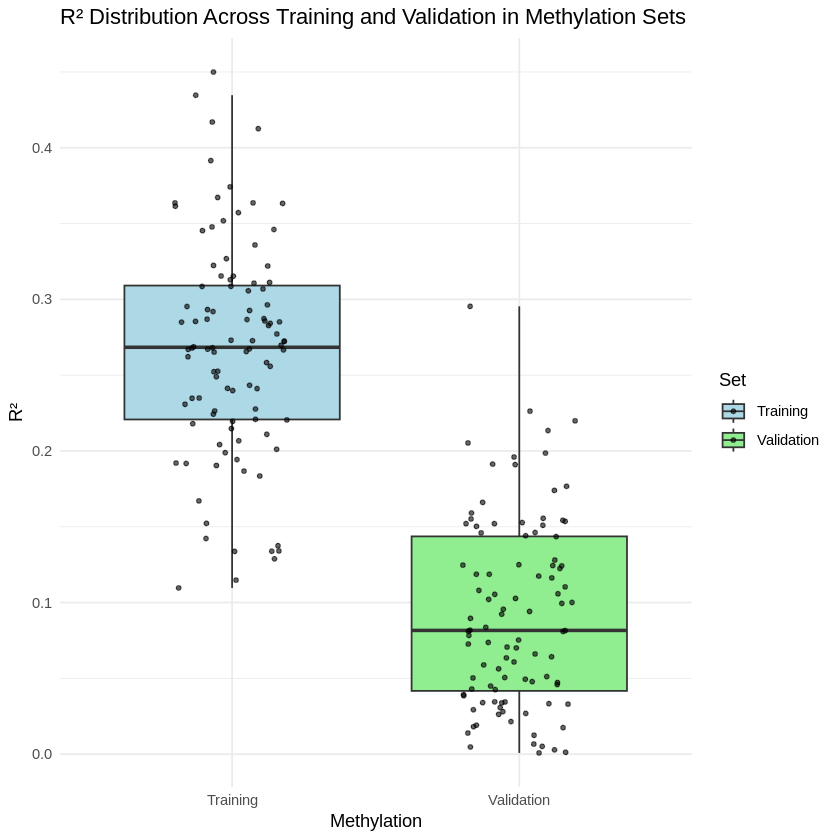

In [21]:
 plot_data_r2 <- data.frame(
  Set = rep(c("Training", "Validation"), each = 100),
  R2 = c(train_r2_values, val_r2_values)
)                                            
# Plot only R²
# ppi <- 300
# png("/vol/projects/yzhang/500FG_aging/output/12_prediction/cytokine_predicition_pvalue_common_select_spearman.png", 
#     width = 5 * ppi, height = 4 * ppi, res = ppi)

g<-ggplot(plot_data_r2, aes(x = Set, y = R2, fill = Set)) +
  geom_boxplot(outlier.shape = NA) +  # Boxplot without outliers
  geom_jitter(position = position_jitterdodge(), size = 1, alpha = 0.6, color = "black") +  # Scatter points
  labs(title = "R² Distribution Across Training and Validation in Methylation Sets",
       x = "Methylation",
       y = "R²") +
  theme_minimal() +
  scale_fill_manual(values = c("lightblue", "lightgreen")) +
  theme(axis.text.x = element_text(angle = 0, hjust = 0.5))
print(g)
# dev.off()    
# print(g)

In [31]:
save.image("/vol/projects/yzhang/500FG_aging/output/12_prediction/cytokine_prediction_results_spearman_select_gender.Rdata")

In [3]:
info <- readRDS("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/Mvalue_spearman_prediction_results/iteration_1_info.rds")
str(info)

List of 2
 $ split_indices    : int [1:215, 1] 1 2 3 4 5 6 8 10 17 18 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr "Resample1"
 $ selected_features: chr [1:116] "cg25410668_TC21" "cg07914614_TC21" "cg23078123_BC21" "cg18933331_TC21" ...


In [4]:
info <- readRDS("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/Mvalue_spearman_prediction_results/iteration_2_info.rds")
str(info)

List of 2
 $ split_indices    : int [1:215, 1] 2 4 7 8 9 10 11 12 13 15 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr "Resample1"
 $ selected_features: chr [1:87] "cg12642568_TC21" "cg25410668_TC21" "cg07914614_TC21" "cg23078123_BC21" ...


In [5]:
info <- readRDS("/vol/projects/yzhang/500FG_aging/code/prediction/prediction_vari_spearman/Mvalue_spearman_prediction_results/iteration_3_info.rds")
str(info)

List of 2
 $ split_indices    : int [1:215, 1] 2 3 4 6 8 9 10 11 13 15 ...
  ..- attr(*, "dimnames")=List of 2
  .. ..$ : NULL
  .. ..$ : chr "Resample1"
 $ selected_features: chr [1:107] "cg25410668_TC21" "cg07914614_TC21" "cg13697378_BC11" "cg23078123_BC21" ...
